# Breadth First Search from Scratch: 
## Shortest Path in Romania Map


**Plan**
1. Build the Graph network
2. Describe it as a *problem* (initial state, goal test, actions)
3. Create the *Node* that remembers where it came from
4. Write BFS exactly like the pseudocode
5. Visualize the search step by step, inside the notebook

### Step 0: Module Import

In [1]:
import time
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx

from collections import deque
from IPython.display import clear_output

### Step 1: The Social Network

citieship is two-way, so each edge is added in both directions.
The graph is a plain Python dictionary: `person -> list of cities`.

In [2]:
edges = [
    ("Oradea", "Zerind"),
    ("Zerind", "Arad"),
    ("Oradea", "Sibiu"),
    ("Arad", "Sibiu"),
    ("Arad", "Timisoara"),
    ("Sibiu", "Fagaras"),
    ("Sibiu", "Rimnicu Vilcea"),
    ("Timisoara", "Lugoj"),
    ("Lugoj", "Mehadia"),
    ("Mehadia", "Drobeta"),
    ("Drobeta", "Craiova"),
    ("Rimnicu Vilcea", "Craiova"),
    ("Rimnicu Vilcea", "Pitesti"),
    ("Craiova", "Pitesti"),
    ("Pitesti", "Bucharest"),
    ("Fagaras", "Bucharest"),
    ("Bucharest", "Giurgiu"),
    ("Bucharest", "Urziceni"),
    ("Urziceni", "Vaslui"),
    ("Urziceni", "Hirsova"),
    ("Hirsova", "Eforie"),
    ("Vaslui", "Iasi"),
    ("Iasi", "Neamt"),
]

cities = {}

for a, b in edges:
    cities.setdefault(a, []).append(b)
    cities.setdefault(b, []).append(a)

print("Arad's Connections", cities["Arad"])
print("Total cities :", len(cities))



# Note: setdefault(): dict.setdefault(keyname, value)
# If the key is already in the dictionary, setdefault() returns the existing value and does not change the dictionary.
# If the key is not in the dictionary, it adds the key with your provided value and returns that new value.


Arad's Connections ['Zerind', 'Sibiu', 'Timisoara']
Total cities : 20


### Step 2: Define the Problem

In [3]:
class SixDegreeProblem:
    # graph = cities
    
    def __init__(self, graph, initialState, goalState):
        self.graph = graph
        self.initialState = initialState
        self.goalState = goalState
    
    def goalTest(self, state):
        return state == self.goalState
    
    def actions(self, state):
        # an action is simply "move to friend X", so we return the cities
        return self.graph[state]
    
    def result(self, state, action):
        # moving to friend X puts us in state X
        return action

### Step 3: The Node

A **node** is not the same thing as a state. It wraps a state and remembers:
- `parent`: the node we came from (this is how we rebuild the path later)
- `action`: what we did to get here
- `path_cost`: number of handshakes so far

`child_node(...)` is `CHILD-NODE` from the pseudocode, and `solution(...)` is `SOLUTION`.

In [4]:
class Node:
    def __init__(self, state, parent=None, action=None, pathCost=0):
        self.state = state
        self.parent = parent
        self.action = action
        self.pathCost = pathCost
    
def childNode(problem, parent, action):
    state = problem.result(parent.state, action)
    return Node(state, parent, action, parent.pathCost + 1)

def solution(node):
    path = []
    while node is not None:
        path.append(node.state)
        node = node.parent
    
    path.reverse()
    return path



In [5]:
def saveSnapshot(history, current, explored, frontier):
    if history is not None:
        history.append({
            "current": current,
            "explored": set(explored),
            "frontier": [n.state for n in frontier],
        })

### Step 4: Breadth First Search Algorithm

In [6]:
def breadthFirstSearch(problem, history=None):
    node = Node(problem.initialState)

    if problem.goalTest(node.state):
        return solution(node)
    
    frontier = deque([node])
    frontierStates = {node.state}

    explored = set()

    while True:
        if len(frontier) == 0:
            return None
        
        node = frontier.popleft()
        frontierStates.remove(node.state)

        explored.add(node.state)

        for action in problem.actions(node.state):
            child = childNode(problem, node, action)

            if child.state not in explored and child.state not in frontierStates:
                if problem.goalTest(child.state):
                    saveSnapshot(history, child.state, explored, frontier)
                    return solution(child)
            
                frontier.append(child)
                frontierStates.add(child.state)
        saveSnapshot(history, node.state, explored, frontier)


### Step 5: Run it

In [7]:
start = "Arad"
goal = "Bucharest"

problem = SixDegreeProblem(cities, start, goal)
path = breadthFirstSearch(problem)

print("From:", start)
print("To  :", goal)
print("Path:", " -> ".join(path))
print("Degrees of separation:", len(path) - 1)

From: Arad
To  : Bucharest
Path: Arad -> Sibiu -> Fagaras -> Bucharest
Degrees of separation: 3


### Try the edge cases

In [8]:
print(breadthFirstSearch(SixDegreeProblem(cities, "Arad", "Eforie")))

['Arad', 'Sibiu', 'Fagaras', 'Bucharest', 'Urziceni', 'Hirsova', 'Eforie']


### Step 6: Draw the Network

`networkx` only computes node positions and draws. We compute the layout **once**, so people stay in the same place in every picture.

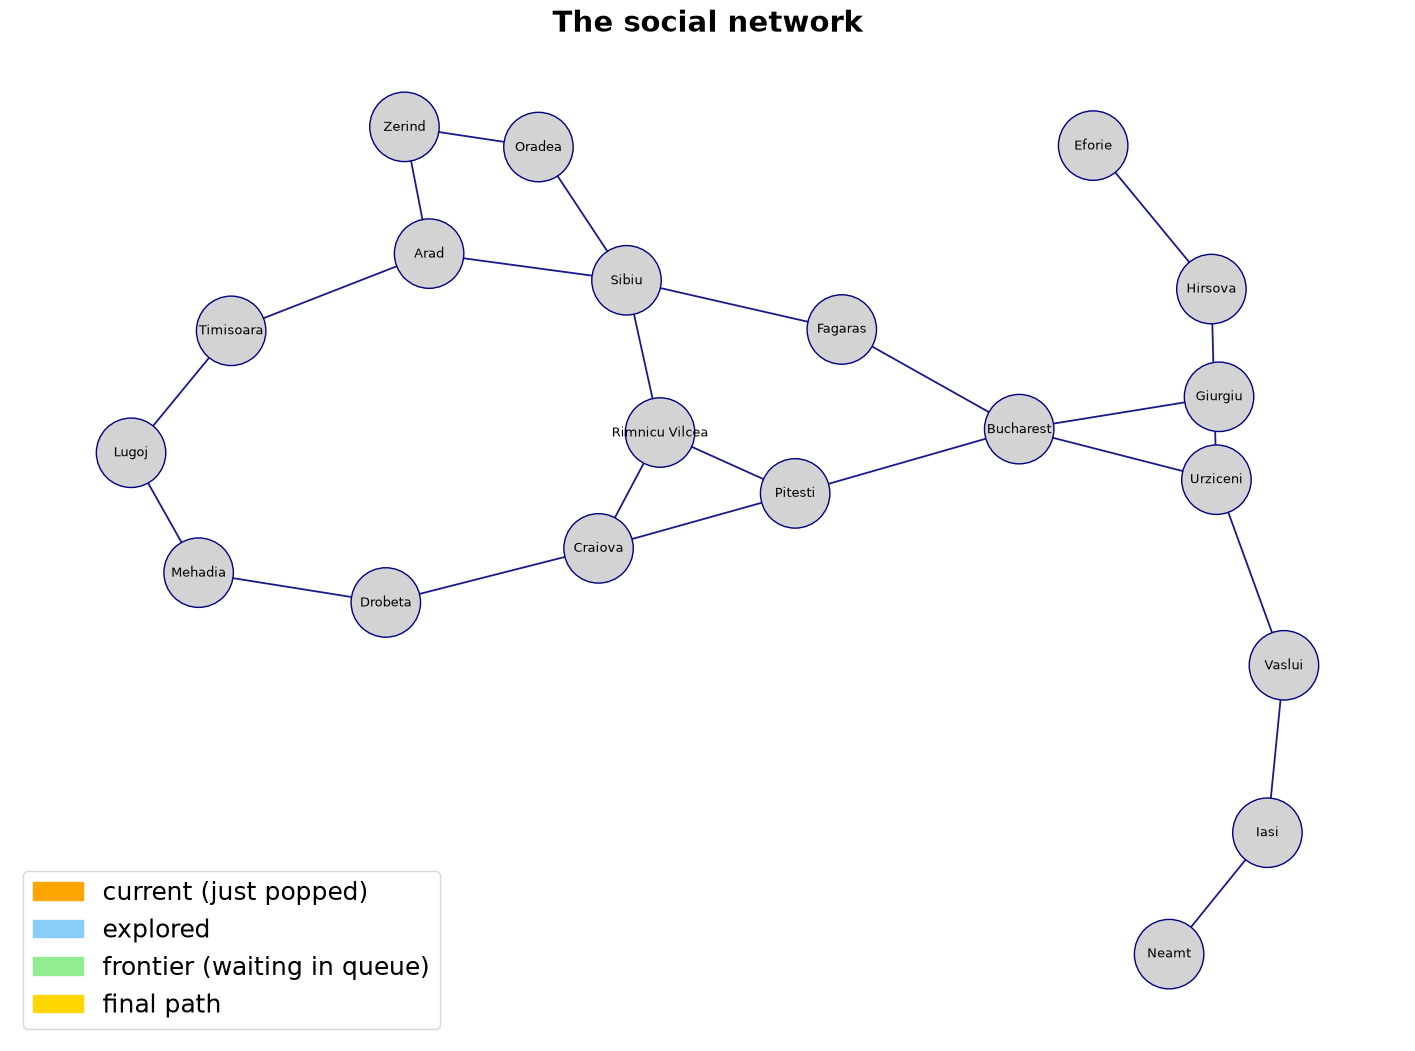

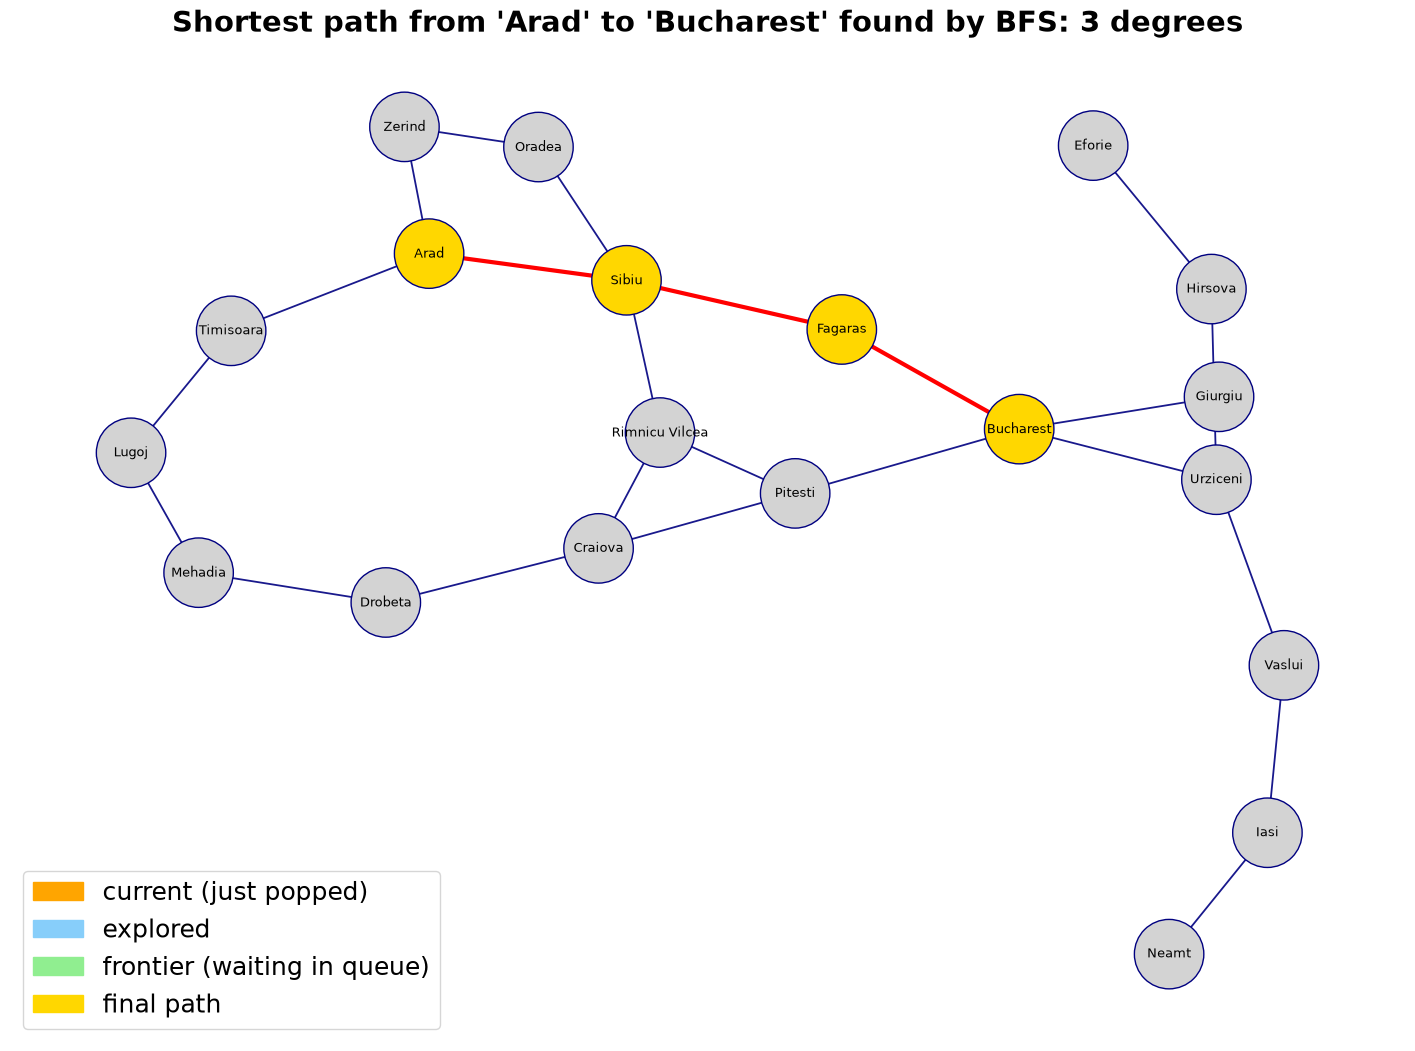

In [9]:
G = nx.Graph()
G.add_edges_from(edges)
pos = nx.spring_layout(G, k=0.6, iterations=100, seed=7)


def draw_graph(snapshot=None, path=None, title=""):
    colors = []
    for person in G.nodes:
        if path and person in path:
            colors.append("gold")
        elif snapshot and person == snapshot["current"]:
            colors.append("orange")
        elif snapshot and person in snapshot["explored"]:
            colors.append("lightskyblue")
        elif snapshot and person in snapshot["frontier"]:
            colors.append("lightgreen")
        else:
            colors.append("lightgray")

    path_edges = list(zip(path, path[1:])) if path else []

    plt.figure(figsize=(18, 13))
    nx.draw_networkx_edges(G, pos, edge_color="navy", alpha=0.9, width=1.3)
    if path_edges:
        nx.draw_networkx_edges(G, pos, edgelist=path_edges, edge_color="red", width=3)
    
    nx.draw_networkx_nodes(G, pos, node_color=colors, node_size=2500, edgecolors="navy")

    # if start:
    #     nx.draw_networkx_nodes(G, pos, nodelist=[start], node_color="lightcoral", node_size=2500, edgecolors="red", linewidths=1.5)
    
    # if goal:
    #     nx.draw_networkx_nodes(G, pos, nodelist=[goal], node_color="lightgreen", node_size=2500, edgecolors="red", linewidths=1.5)
            

    nx.draw_networkx_labels(G, pos, font_size=9)

    legend = [
        mpatches.Patch(color="orange", label="current (just popped)"),
        mpatches.Patch(color="lightskyblue", label="explored"),
        mpatches.Patch(color="lightgreen", label="frontier (waiting in queue)"),
        mpatches.Patch(color="gold", label="final path"),
    ]
    plt.legend(handles=legend, loc="lower left", fontsize=18)
    plt.title(title, fontsize=21, weight="bold")
    plt.axis("off")
    plt.show()

start = "Arad"
goal = "Bucharest"
draw_graph(title="The social network")
draw_graph(path=path, title=f"Shortest path from '{start}' to '{goal}' found by BFS: " + str(len(path) - 1) + " degrees")

### Step 7: Watch BFS think (animation)

We run BFS again, this time with a `history` list, and replay each step.
Notice the waves: everyone at distance 1 is explored before anyone at distance 2. That is what a FIFO queue gives you.

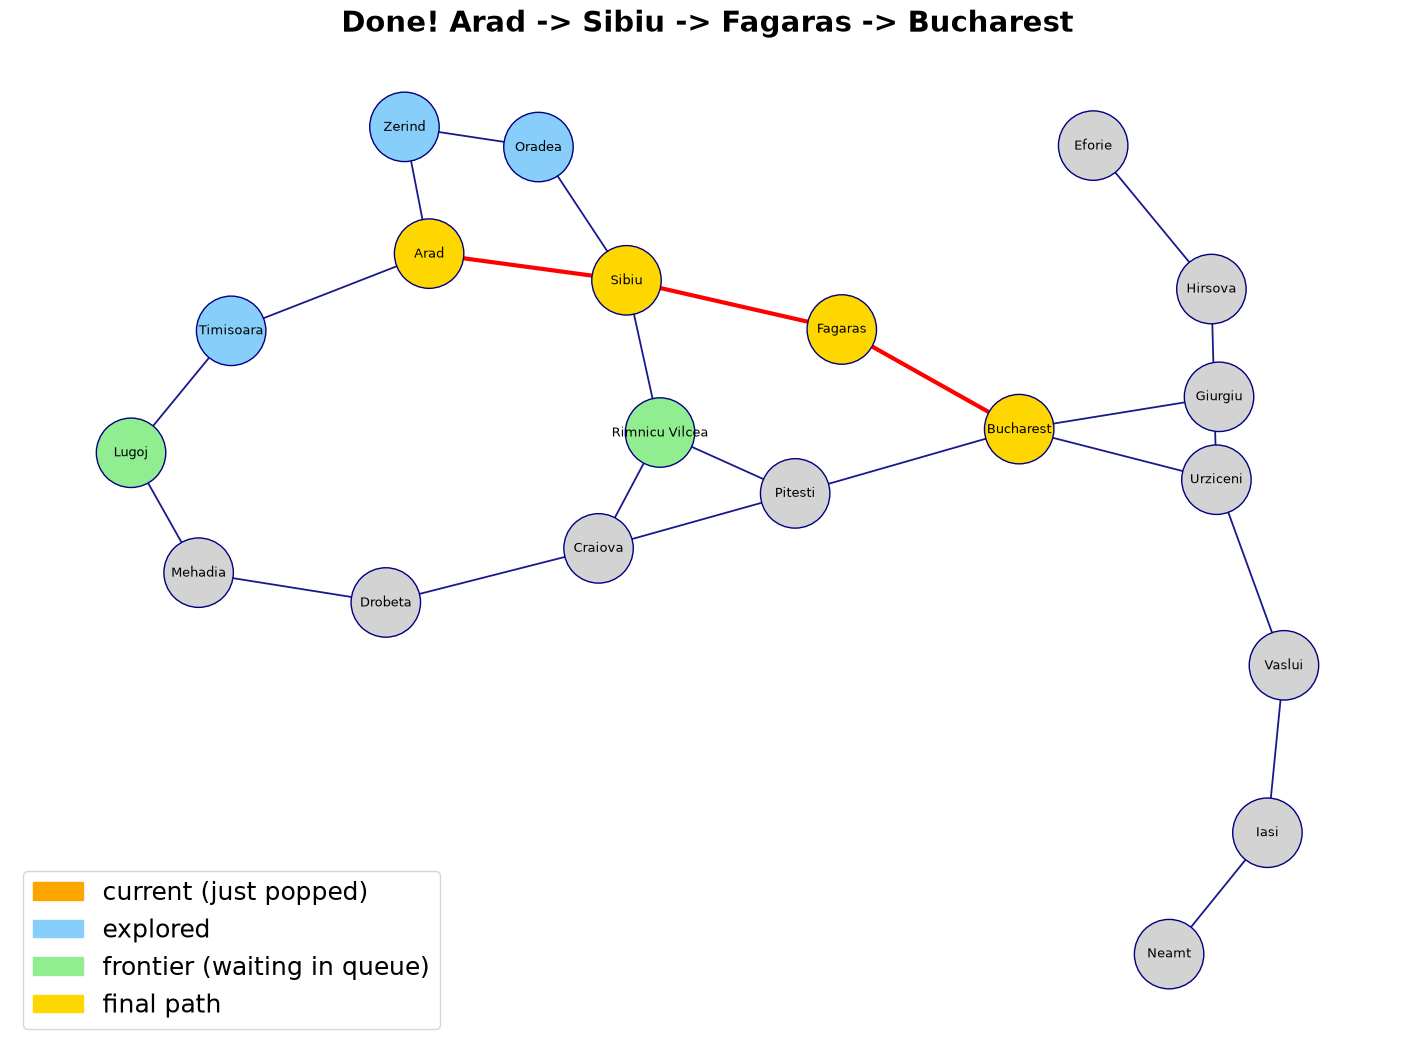

In [10]:
history = []
path = breadthFirstSearch(problem, history)

for step, snap in enumerate(history, start=1):
    clear_output(wait=True)
    draw_graph(snap, title="Step " + str(step) + ": expanding " + snap["current"])
    time.sleep(0.8)

clear_output(wait=True)
draw_graph(history[-1], path=path, title="Done! " + " -> ".join(path))

### Step 8: Read the queue as text


In [11]:
for step, snap in enumerate(history, start=1):
    print("Step", step, "| popped:", snap["current"])
    print("   frontier:", snap["frontier"])
    print("   explored:", sorted(snap["explored"]))

Step 1 | popped: Arad
   frontier: ['Zerind', 'Sibiu', 'Timisoara']
   explored: ['Arad']
Step 2 | popped: Zerind
   frontier: ['Sibiu', 'Timisoara', 'Oradea']
   explored: ['Arad', 'Zerind']
Step 3 | popped: Sibiu
   frontier: ['Timisoara', 'Oradea', 'Fagaras', 'Rimnicu Vilcea']
   explored: ['Arad', 'Sibiu', 'Zerind']
Step 4 | popped: Timisoara
   frontier: ['Oradea', 'Fagaras', 'Rimnicu Vilcea', 'Lugoj']
   explored: ['Arad', 'Sibiu', 'Timisoara', 'Zerind']
Step 5 | popped: Oradea
   frontier: ['Fagaras', 'Rimnicu Vilcea', 'Lugoj']
   explored: ['Arad', 'Oradea', 'Sibiu', 'Timisoara', 'Zerind']
Step 6 | popped: Bucharest
   frontier: ['Rimnicu Vilcea', 'Lugoj']
   explored: ['Arad', 'Fagaras', 'Oradea', 'Sibiu', 'Timisoara', 'Zerind']
